In [2]:
100*(2/8)

25.0

In [3]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

# Load CSV
df = pd.read_csv('../errors_with_status.csv')

# Build ann1 from 'status' column
ann1 = df['status'].tolist()

# Make a copy for ann2
ann2 = ann1.copy()

# Flags to ensure only one change per rule
change1_done = False
change2_done = False
change3_done = False

# Single loop to apply all changes safely
for i, val in enumerate(ann2):
    # 1. Replace 1 instance of "hallucinated and incorrect" with "hallucinated and corrected"
    if not change1_done and val == "hallucinated and corrected" and ann1[i] == "hallucinated and corrected":
        ann2[i] = "hallucinated and incorrect"
        change1_done = True
        print("Changed entry", i, "from 'hallucinated and corrected' to 'hallucinated and incorrect'")
        continue  # skip to next iteration

    # 2. Replace 1 instance of "hallucinated and incorrect" with "preserved"
    # Only consider original values from ann1, not ones already changed
    if not change2_done and val == "preserved" and ann1[i] == "preserved":
        ann2[i] = "hallucinated and incorrect"
        change2_done = True
        print("Changed entry", i, "from 'preserved' to 'hallucinated and incorrect'")
        continue

    # 3. Replace 1 instance of "preserved" with "hallucination but correct"
    # Only consider original values from ann1
    if not change3_done and val == "hallucinated and corrected" and ann1[i] == "hallucinated and corrected":
        ann2[i] = "preserved"
        change3_done = True
        print("Changed entry", i, "from 'hallucinated and correct' to 'preserved'")
        continue


kappa = cohen_kappa_score(ann1, ann2)

print(f"Cohen's Kappa: {kappa:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: '../errors_with_status.csv'

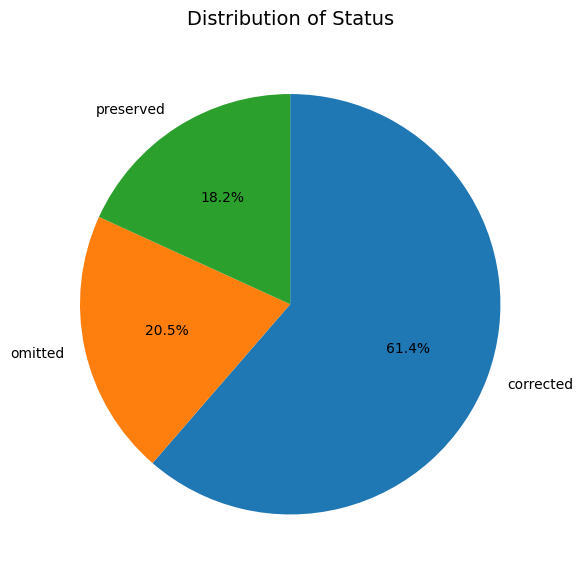

/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_35125/4074470045.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["section", "status"])


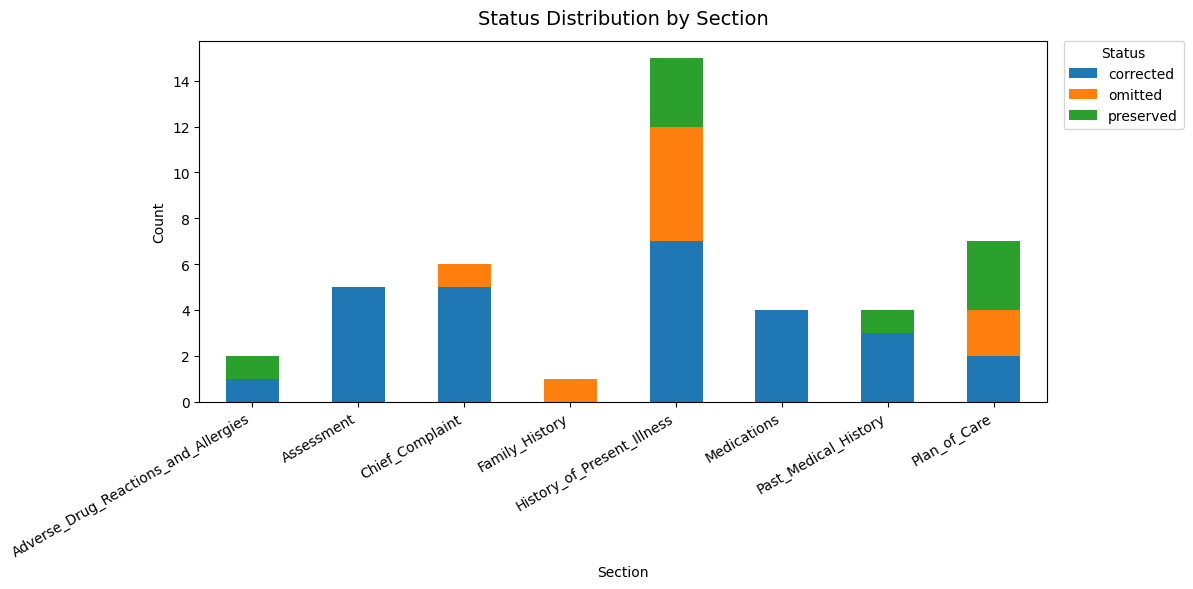

/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_35125/4074470045.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["status", "error_type"])
/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_35125/4074470045.py:107: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["error_type", "status"])


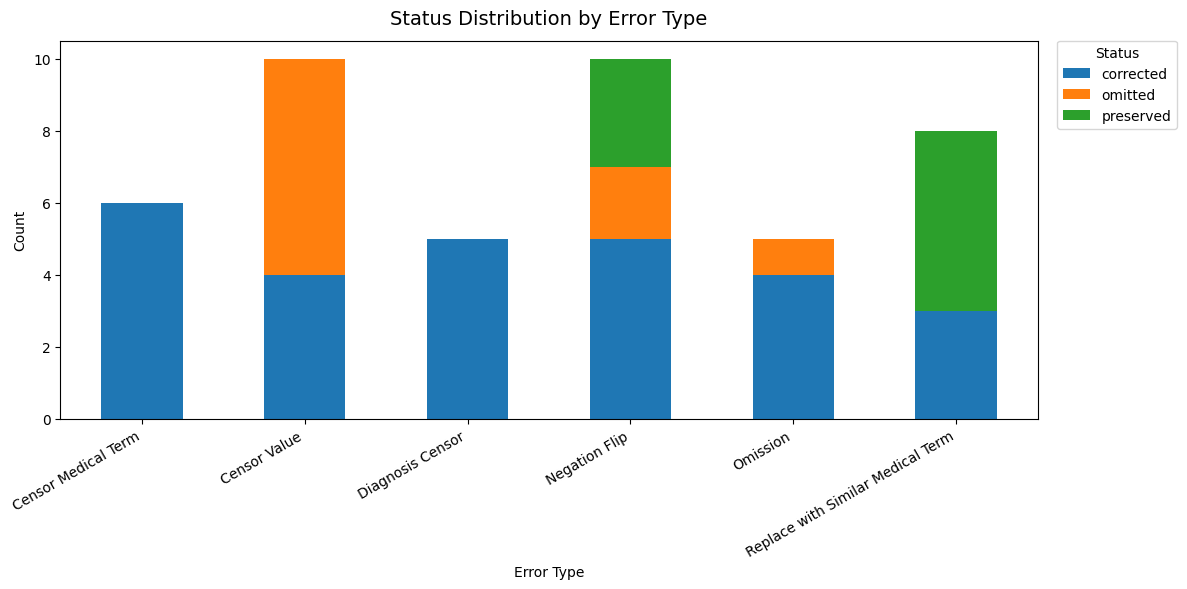

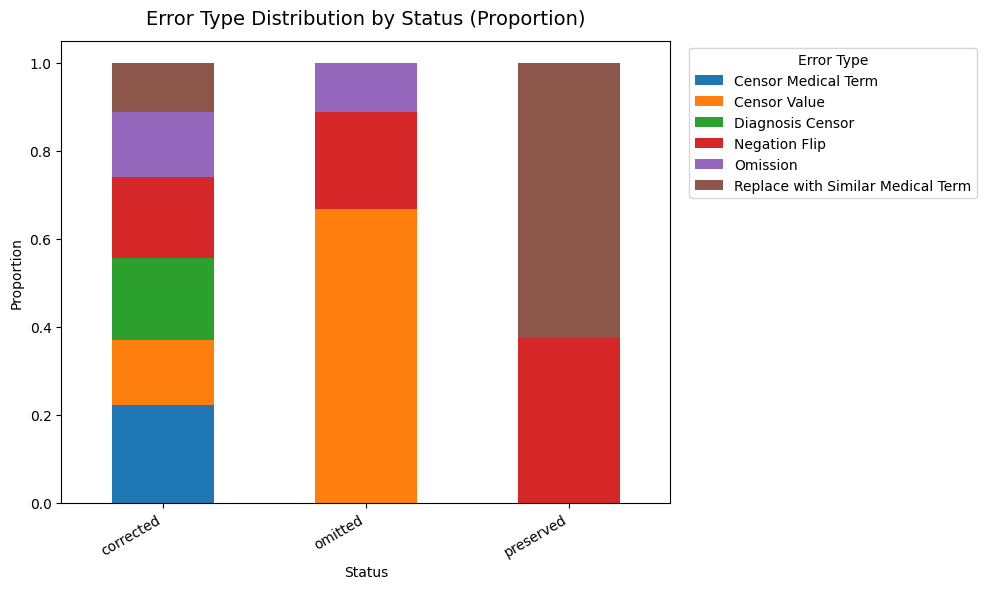

/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_35125/4074470045.py:161: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["section", "error_type", "status"])
/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_35125/4074470045.py:166: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for section, subdf in status_by_section_error.groupby(level=0):


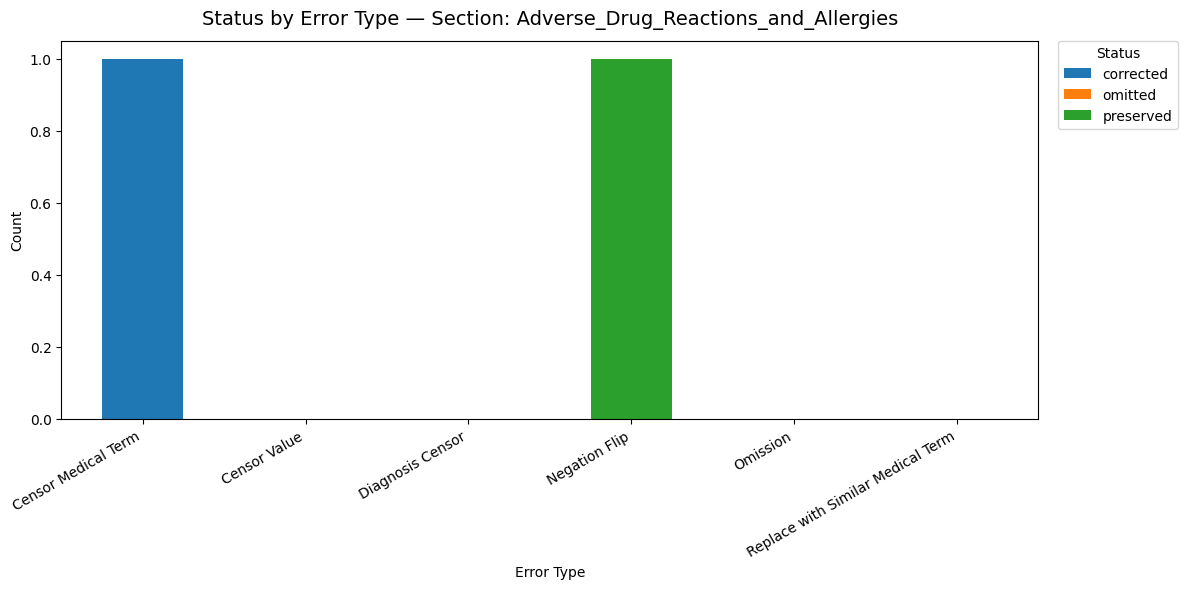

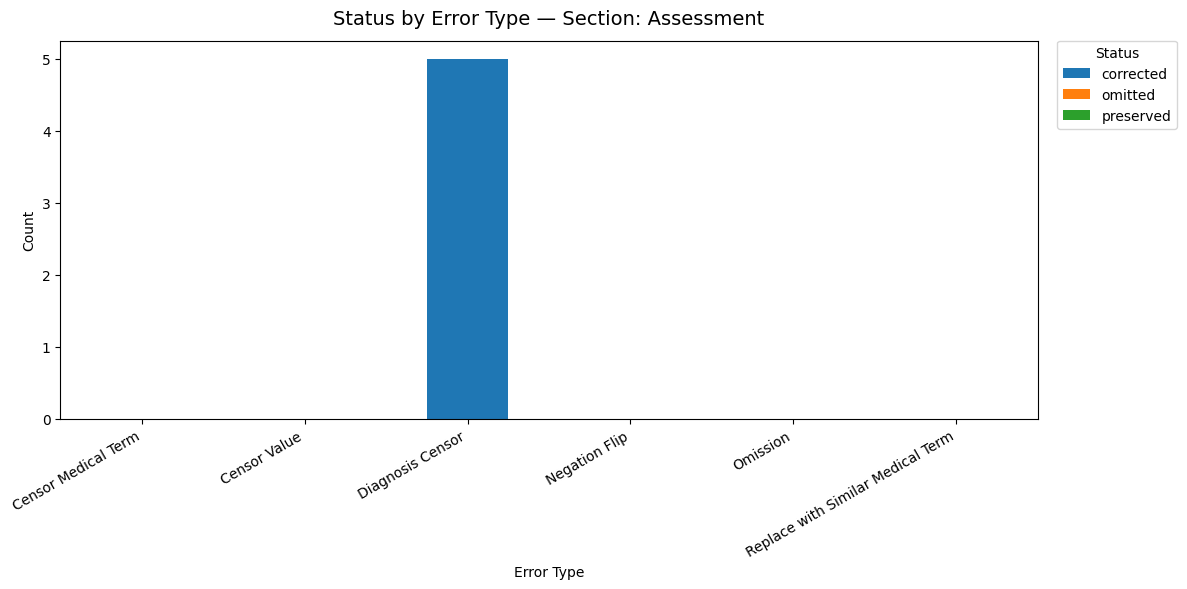

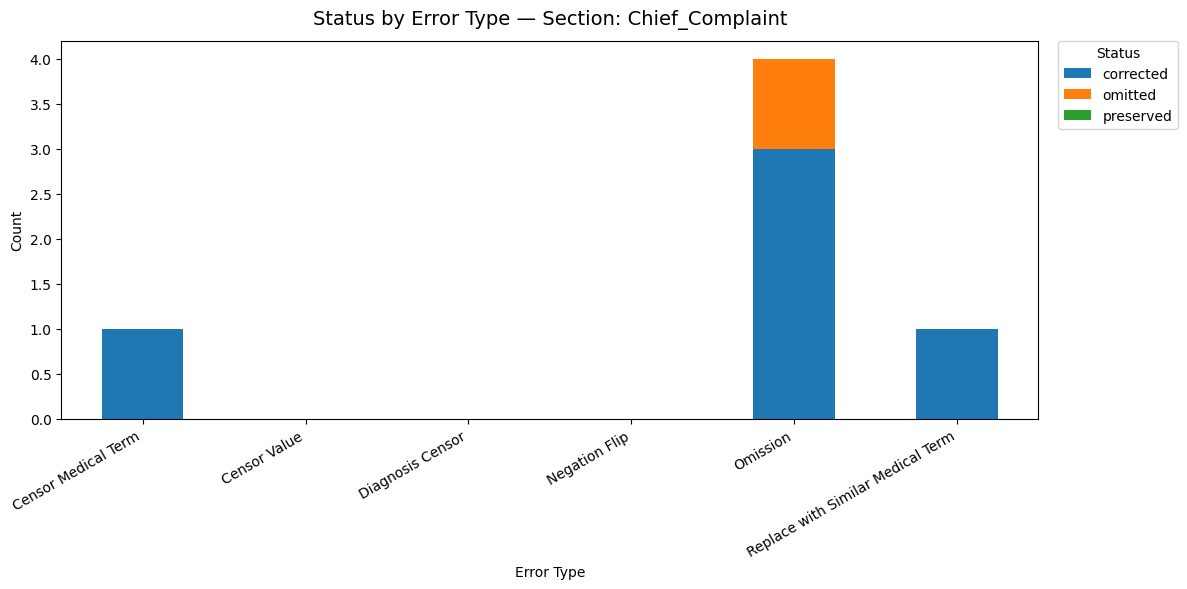

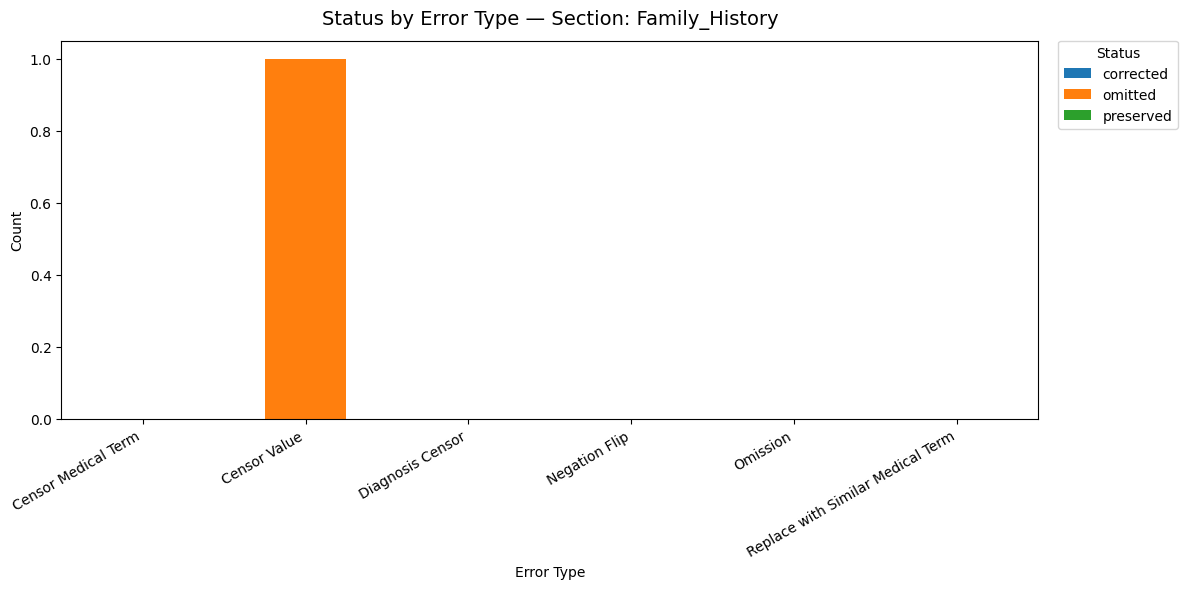

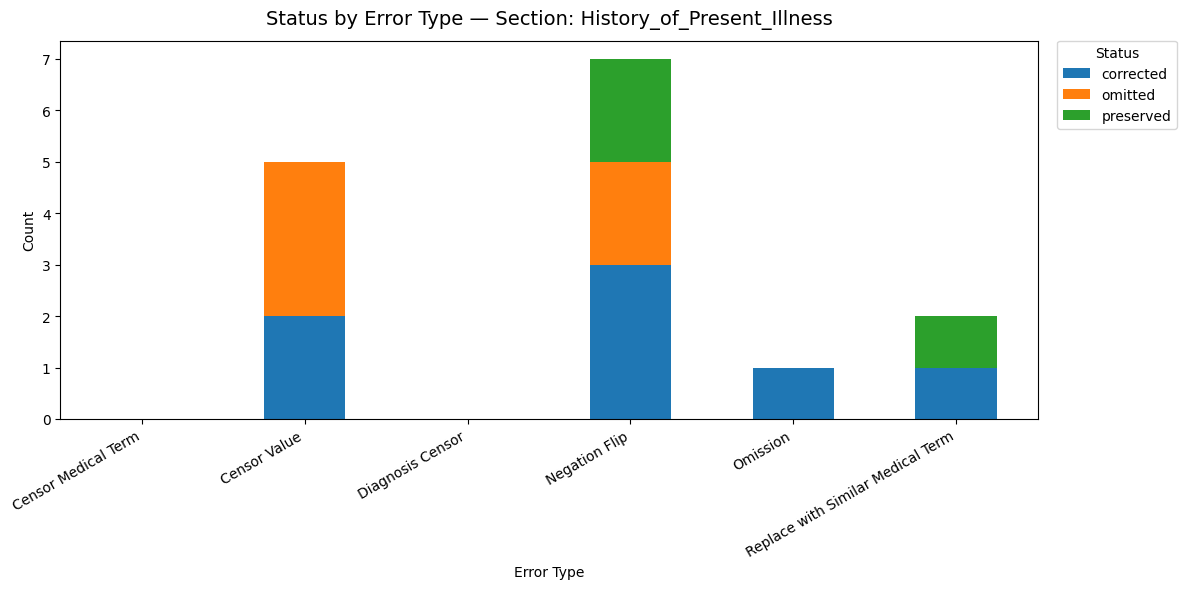

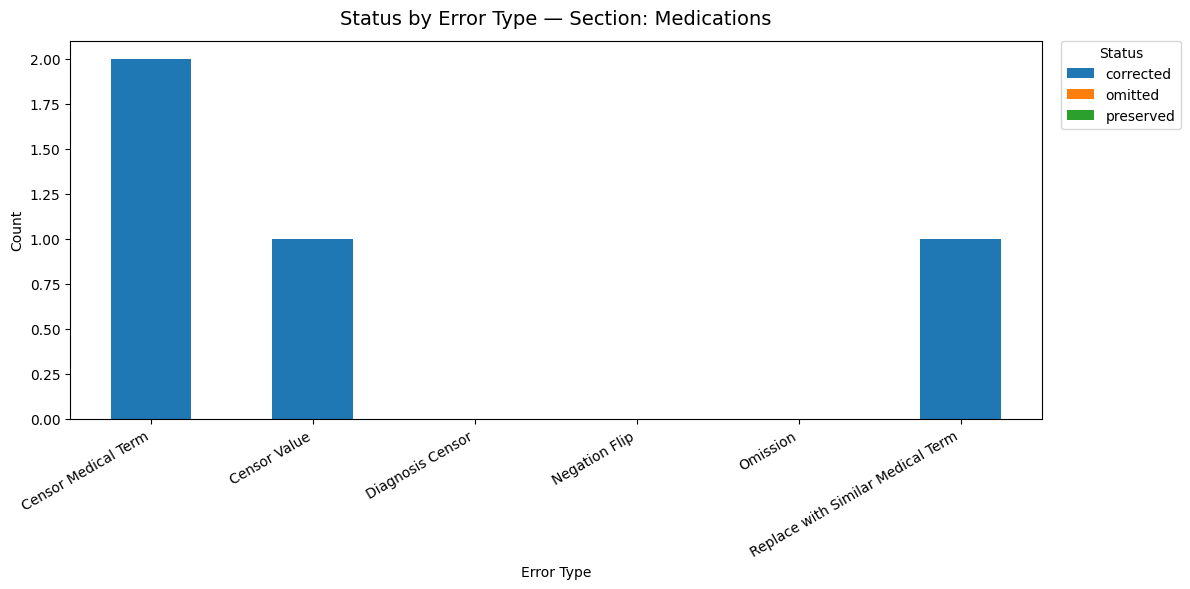

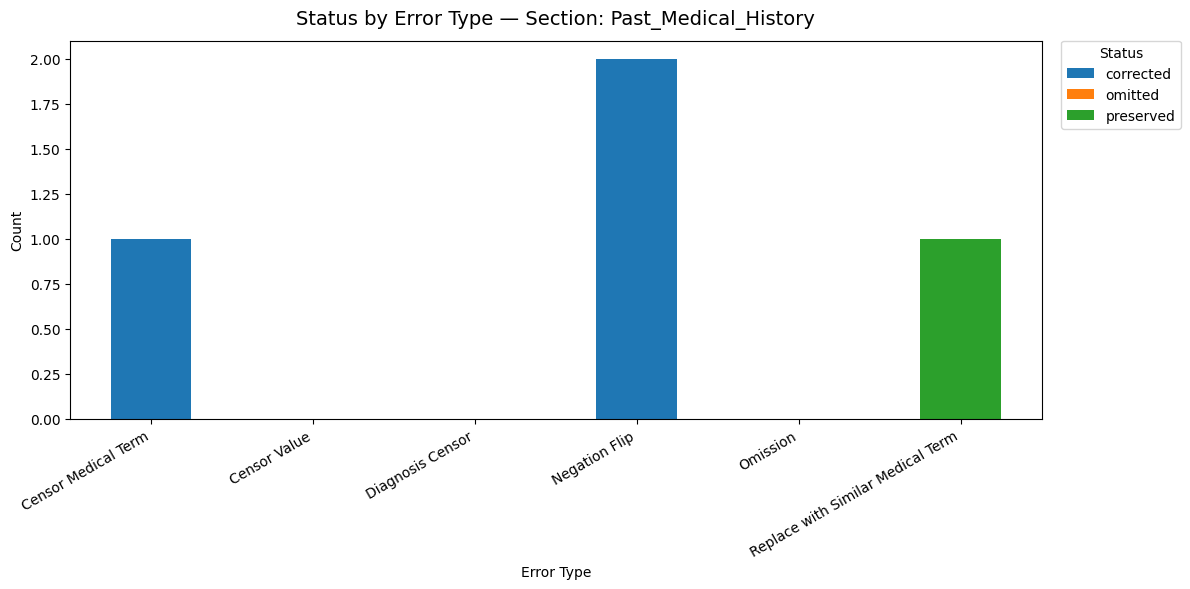

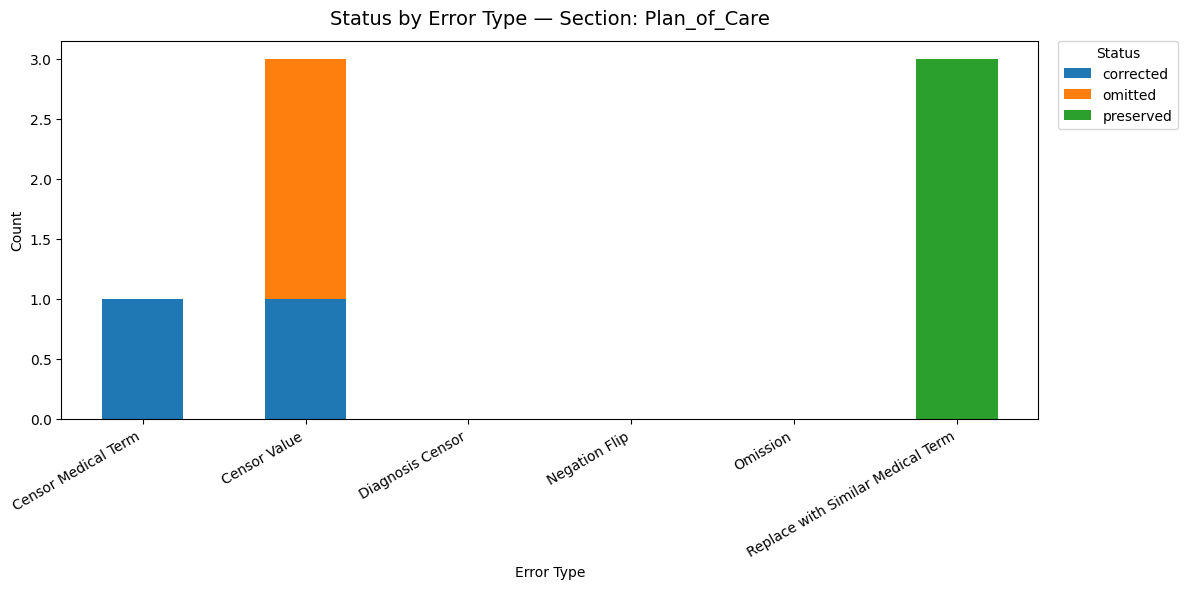

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load data
# -------------------------
df = pd.read_csv("errors_with_status.csv")
df['status'] = df['status'].replace('hallucinated and corrected', 'corrected')

# Ensure categorical columns
cols = ["status", "section", "error_type"]
for c in cols:
    df[c] = df[c].astype("category")

# Optional: consistent ordering
df["status"] = df["status"].cat.as_ordered()

# -------------------------
# Helper plotting function
# -------------------------
def plot_stacked_bar(
    df,
    title,
    xlabel,
    ylabel="Count",
    figsize=(10, 6),
    rotate_xticks=30
):
    ax = df.plot(
        kind="bar",
        stacked=True,
        figsize=figsize
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=rotate_xticks,
        ha="right"
    )

    # Legend outside plot
    ax.legend(
        title="Status",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()

# -------------------------
# 1. Overall distribution of status
# -------------------------
# Count status
status_counts = df["status"].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

plt.title("Distribution of Status", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# -------------------------
# 2. Status stratified by section
# -------------------------
status_by_section = (
    df.groupby(["section", "status"])
      .size()
      .unstack(fill_value=0)
)

plot_stacked_bar(
    status_by_section,
    title="Status Distribution by Section",
    xlabel="Section",
    figsize=(12, 6)
)

# -------------------------
# 3. Status stratified by error_type
# -------------------------
status_error_counts = (
    df.groupby(["status", "error_type"])
      .size()
      .unstack(fill_value=0)
)

# Optional: sort status by total count
status_error_counts = status_error_counts.loc[
    status_error_counts.sum(axis=1).sort_values(ascending=False).index
]

status_by_error_type = (
    df.groupby(["error_type", "status"])
      .size()
      .unstack(fill_value=0)
)

plot_stacked_bar(
    status_by_error_type,
    title="Status Distribution by Error Type",
    xlabel="Error Type",
    figsize=(12, 6)
)


# Ensure categorical
df["status"] = df["status"].astype("category")
df["error_type"] = df["error_type"].astype("category")

status_error_props = status_error_counts.div(
    status_error_counts.sum(axis=1),
    axis=0
)

fig, ax = plt.subplots(figsize=(10, 6))

status_error_props.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Error Type Distribution by Status (Proportion)", fontsize=14, pad=12)
ax.set_xlabel("Status")
ax.set_ylabel("Proportion")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

ax.legend(
    title="Error Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# -------------------------
# 4. Status stratified by BOTH section and error_type
# -------------------------
status_by_section_error = (
    df.groupby(["section", "error_type", "status"])
      .size()
      .unstack(fill_value=0)
)

for section, subdf in status_by_section_error.groupby(level=0):
    subdf = subdf.droplevel(0)

    plot_stacked_bar(
        subdf,
        title=f"Status by Error Type — Section: {section}",
        xlabel="Error Type",
        figsize=(12, 6)
    )



Overall status counts


,count
status,
corrected,27
omitted,9
preserved,8



Overall status proportions


,proportion
status,
corrected,0.614
omitted,0.205
preserved,0.182


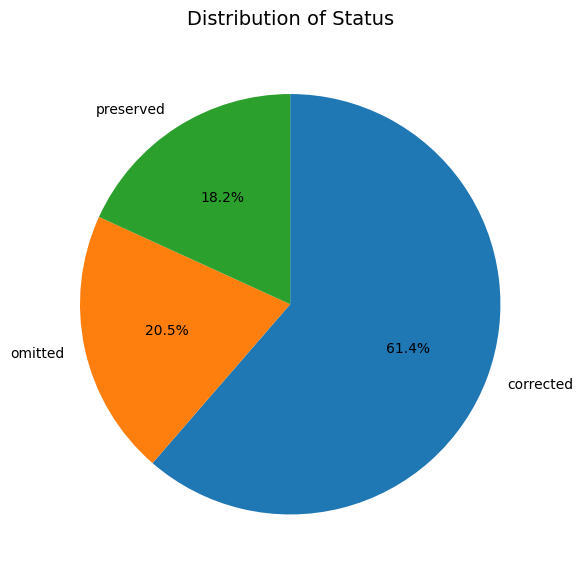


Status by section (counts)


/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_35125/3043980834.py:89: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["section", "status"])


status,corrected,omitted,preserved
section,,,
Adverse_Drug_Reactions_and_Allergies,1,0,1
Assessment,5,0,0
Chief_Complaint,5,1,0
Family_History,0,1,0
History_of_Present_Illness,7,5,3
Medications,4,0,0
Past_Medical_History,3,0,1
Plan_of_Care,2,2,3



Status by section (proportions)


status,corrected,omitted,preserved
section,,,
Adverse_Drug_Reactions_and_Allergies,0.500,0.000,0.500
Assessment,1.000,0.000,0.000
Chief_Complaint,0.833,0.167,0.000
Family_History,0.000,1.000,0.000
History_of_Present_Illness,0.467,0.333,0.200
Medications,1.000,0.000,0.000
Past_Medical_History,0.750,0.000,0.250
Plan_of_Care,0.286,0.286,0.429


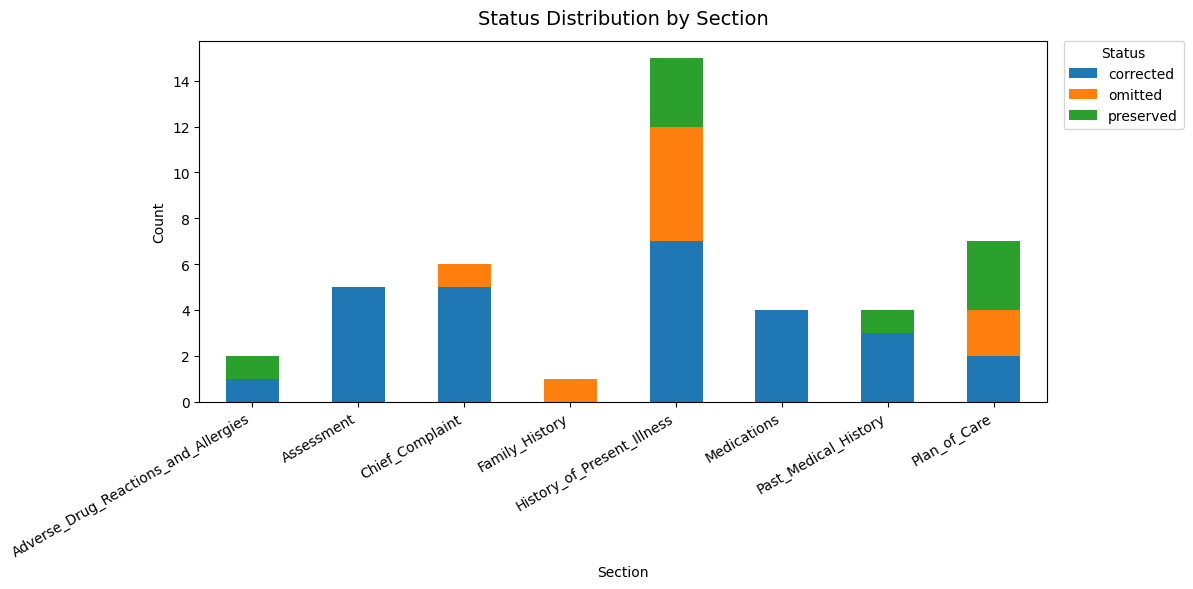


Status by error type (counts)


/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_35125/3043980834.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["error_type", "status"])


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,6,0,0
Censor Value,4,6,0
Diagnosis Censor,5,0,0
Negation Flip,5,2,3
Omission,4,1,0
Replace with Similar Medical Term,3,0,5



Status by error type (proportions)


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,1.000,0.0,0.000
Censor Value,0.400,0.6,0.000
Diagnosis Censor,1.000,0.0,0.000
Negation Flip,0.500,0.2,0.300
Omission,0.800,0.2,0.000
Replace with Similar Medical Term,0.375,0.0,0.625


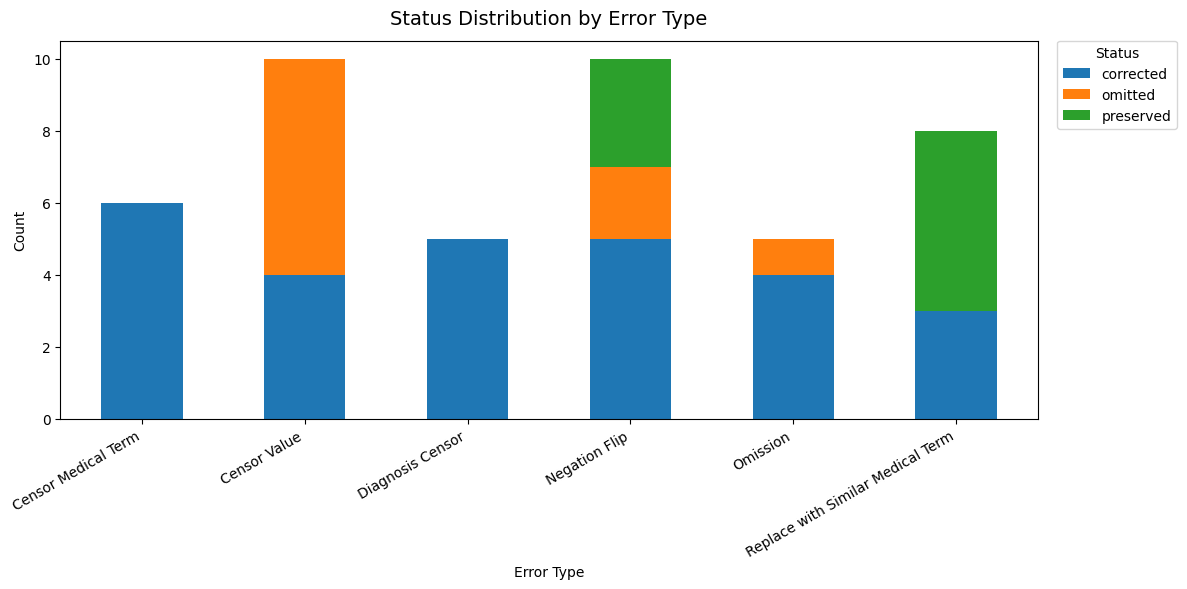


Error type by status (counts)


/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_35125/3043980834.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["status", "error_type"])


error_type,Censor Medical Term,Censor Value,Diagnosis Censor,Negation Flip,Omission,Replace with Similar Medical Term
status,,,,,,
corrected,6,4,5,5,4,3
omitted,0,6,0,2,1,0
preserved,0,0,0,3,0,5



Error type by status (proportions)


error_type,Censor Medical Term,Censor Value,Diagnosis Censor,Negation Flip,Omission,Replace with Similar Medical Term
status,,,,,,
corrected,0.222,0.148,0.185,0.185,0.148,0.111
omitted,0.000,0.667,0.000,0.222,0.111,0.000
preserved,0.000,0.000,0.000,0.375,0.000,0.625


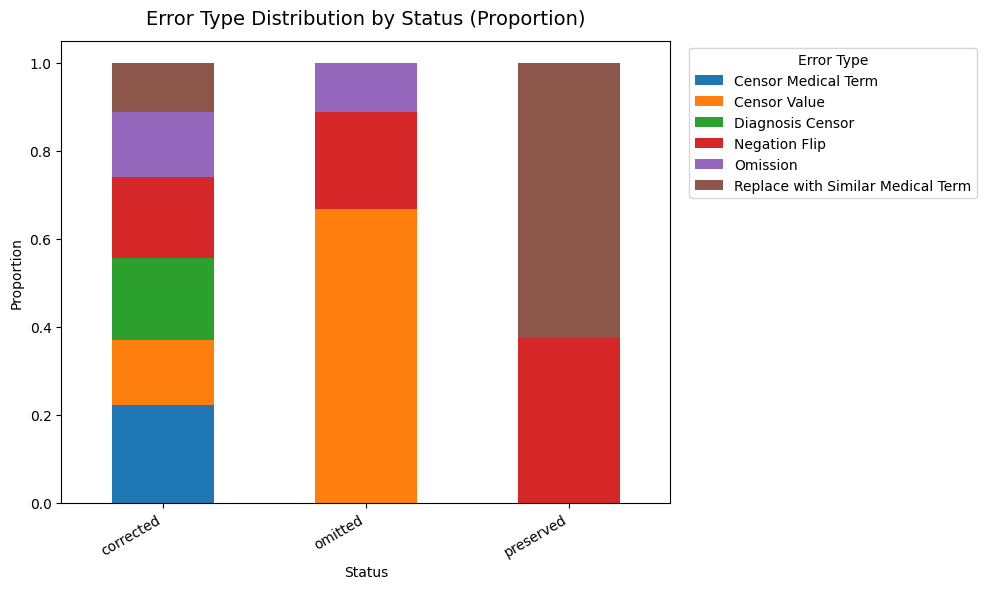


Section: Adverse_Drug_Reactions_and_Allergies — counts


/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_35125/3043980834.py:196: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["section", "error_type", "status"])
/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_35125/3043980834.py:201: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for section, subdf in status_by_section_error.groupby(level=0):


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,1,0,0
Censor Value,0,0,0
Diagnosis Censor,0,0,0
Negation Flip,0,0,1
Omission,0,0,0
Replace with Similar Medical Term,0,0,0


Section: Adverse_Drug_Reactions_and_Allergies — proportions


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,1.0,0.0,0.0
Censor Value,NaN,NaN,NaN
Diagnosis Censor,NaN,NaN,NaN
Negation Flip,0.0,0.0,1.0
Omission,NaN,NaN,NaN
Replace with Similar Medical Term,NaN,NaN,NaN


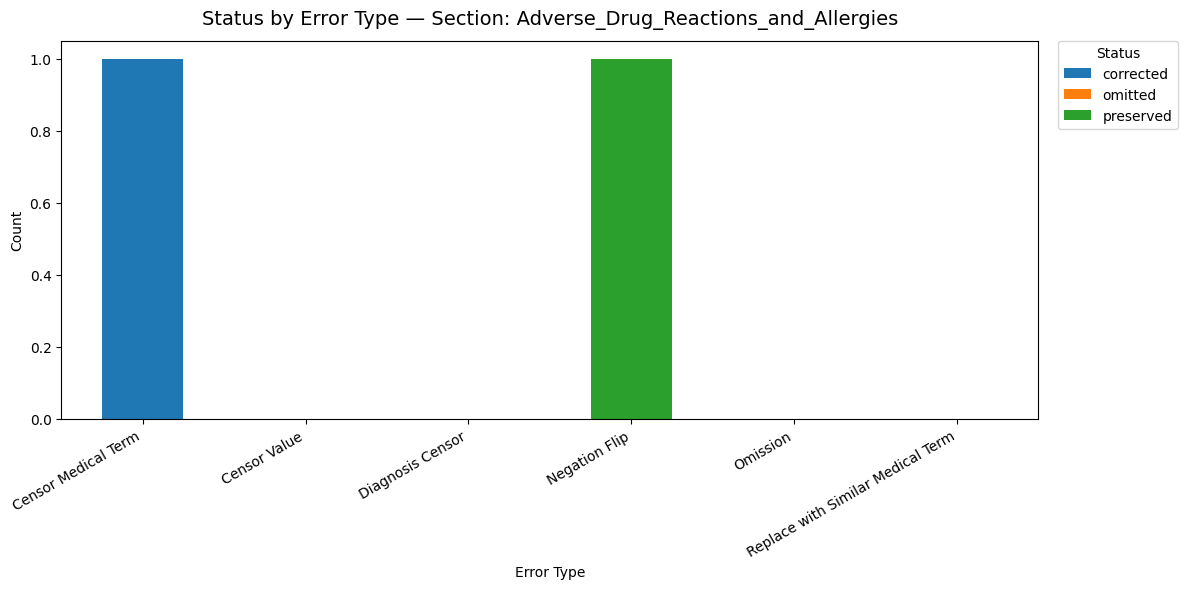


Section: Assessment — counts


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,0,0,0
Censor Value,0,0,0
Diagnosis Censor,5,0,0
Negation Flip,0,0,0
Omission,0,0,0
Replace with Similar Medical Term,0,0,0


Section: Assessment — proportions


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,NaN,NaN,NaN
Censor Value,NaN,NaN,NaN
Diagnosis Censor,1.0,0.0,0.0
Negation Flip,NaN,NaN,NaN
Omission,NaN,NaN,NaN
Replace with Similar Medical Term,NaN,NaN,NaN


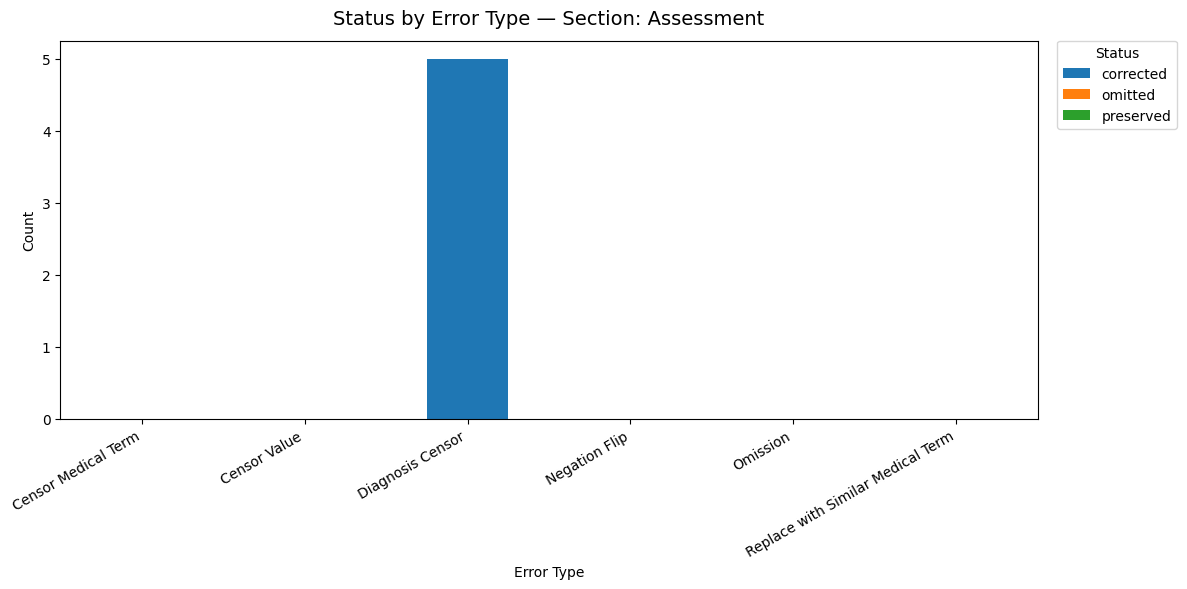


Section: Chief_Complaint — counts


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,1,0,0
Censor Value,0,0,0
Diagnosis Censor,0,0,0
Negation Flip,0,0,0
Omission,3,1,0
Replace with Similar Medical Term,1,0,0


Section: Chief_Complaint — proportions


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,1.00,0.00,0.0
Censor Value,NaN,NaN,NaN
Diagnosis Censor,NaN,NaN,NaN
Negation Flip,NaN,NaN,NaN
Omission,0.75,0.25,0.0
Replace with Similar Medical Term,1.00,0.00,0.0


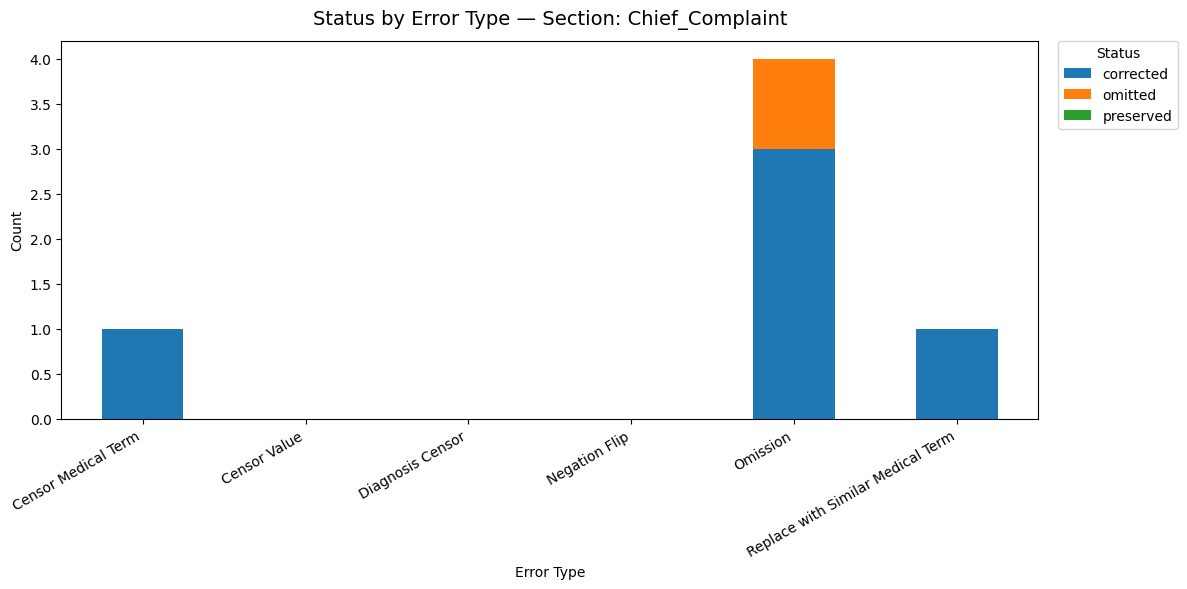


Section: Family_History — counts


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,0,0,0
Censor Value,0,1,0
Diagnosis Censor,0,0,0
Negation Flip,0,0,0
Omission,0,0,0
Replace with Similar Medical Term,0,0,0


Section: Family_History — proportions


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,NaN,NaN,NaN
Censor Value,0.0,1.0,0.0
Diagnosis Censor,NaN,NaN,NaN
Negation Flip,NaN,NaN,NaN
Omission,NaN,NaN,NaN
Replace with Similar Medical Term,NaN,NaN,NaN


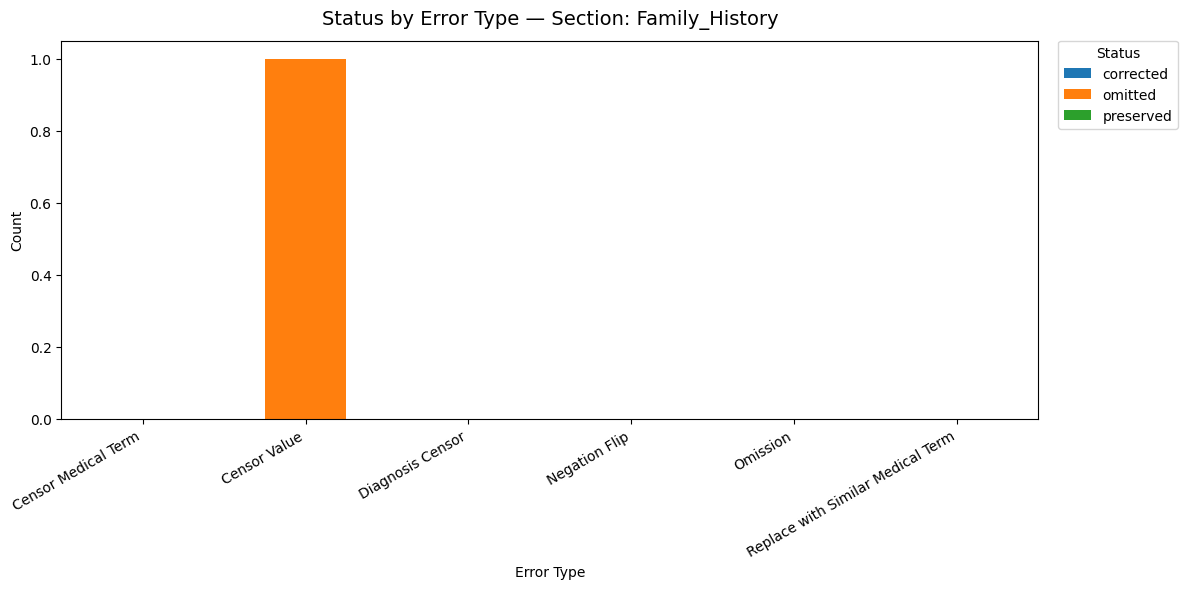


Section: History_of_Present_Illness — counts


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,0,0,0
Censor Value,2,3,0
Diagnosis Censor,0,0,0
Negation Flip,3,2,2
Omission,1,0,0
Replace with Similar Medical Term,1,0,1


Section: History_of_Present_Illness — proportions


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,NaN,NaN,NaN
Censor Value,0.400,0.600,0.000
Diagnosis Censor,NaN,NaN,NaN
Negation Flip,0.429,0.286,0.286
Omission,1.000,0.000,0.000
Replace with Similar Medical Term,0.500,0.000,0.500


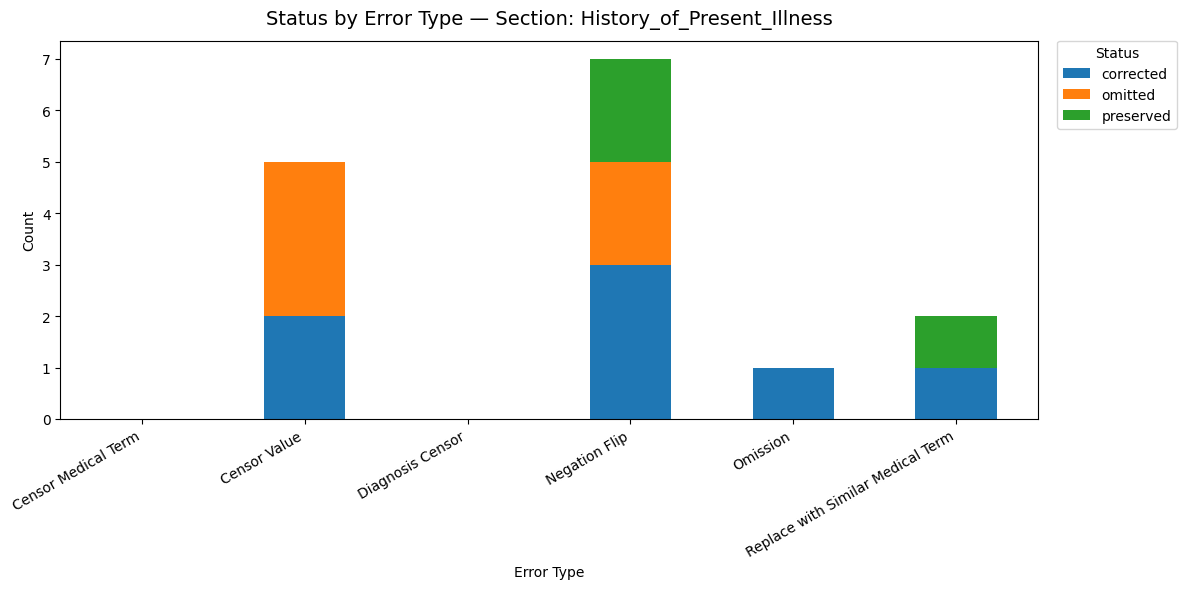


Section: Medications — counts


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,2,0,0
Censor Value,1,0,0
Diagnosis Censor,0,0,0
Negation Flip,0,0,0
Omission,0,0,0
Replace with Similar Medical Term,1,0,0


Section: Medications — proportions


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,1.0,0.0,0.0
Censor Value,1.0,0.0,0.0
Diagnosis Censor,NaN,NaN,NaN
Negation Flip,NaN,NaN,NaN
Omission,NaN,NaN,NaN
Replace with Similar Medical Term,1.0,0.0,0.0


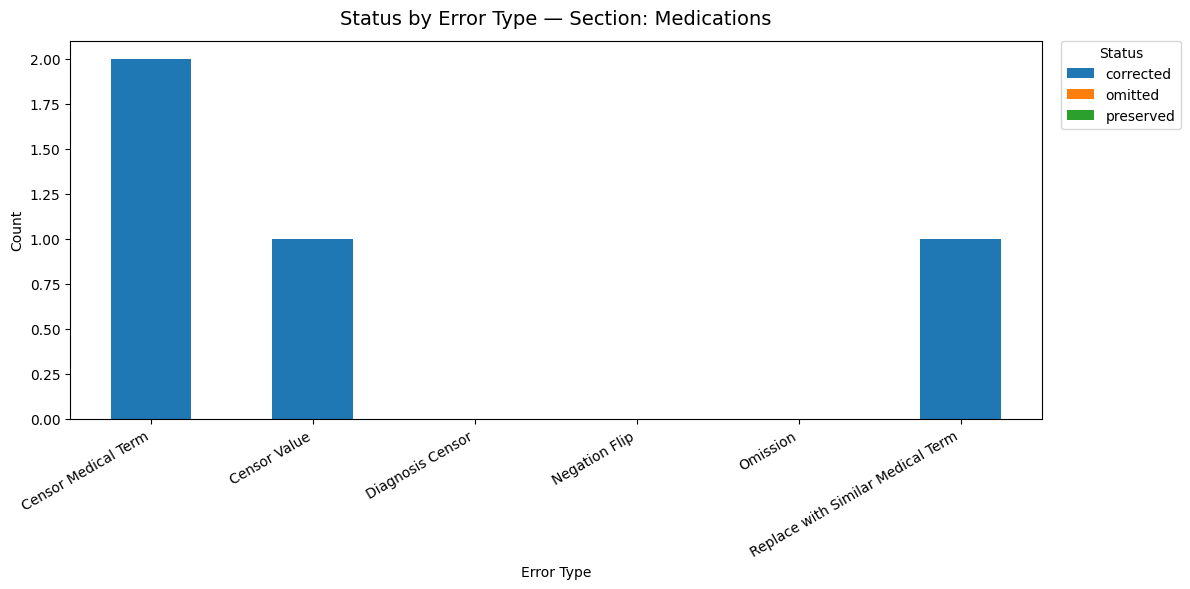


Section: Past_Medical_History — counts


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,1,0,0
Censor Value,0,0,0
Diagnosis Censor,0,0,0
Negation Flip,2,0,0
Omission,0,0,0
Replace with Similar Medical Term,0,0,1


Section: Past_Medical_History — proportions


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,1.0,0.0,0.0
Censor Value,NaN,NaN,NaN
Diagnosis Censor,NaN,NaN,NaN
Negation Flip,1.0,0.0,0.0
Omission,NaN,NaN,NaN
Replace with Similar Medical Term,0.0,0.0,1.0


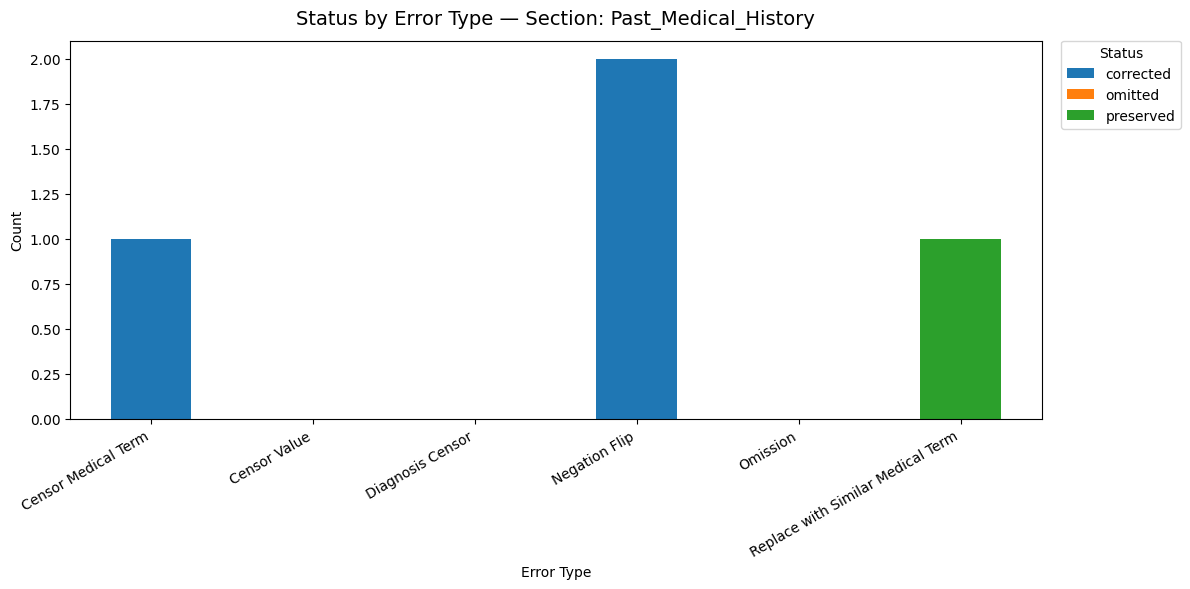


Section: Plan_of_Care — counts


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,1,0,0
Censor Value,1,2,0
Diagnosis Censor,0,0,0
Negation Flip,0,0,0
Omission,0,0,0
Replace with Similar Medical Term,0,0,3


Section: Plan_of_Care — proportions


status,corrected,omitted,preserved
error_type,,,
Censor Medical Term,1.000,0.000,0.0
Censor Value,0.333,0.667,0.0
Diagnosis Censor,NaN,NaN,NaN
Negation Flip,NaN,NaN,NaN
Omission,NaN,NaN,NaN
Replace with Similar Medical Term,0.000,0.000,1.0


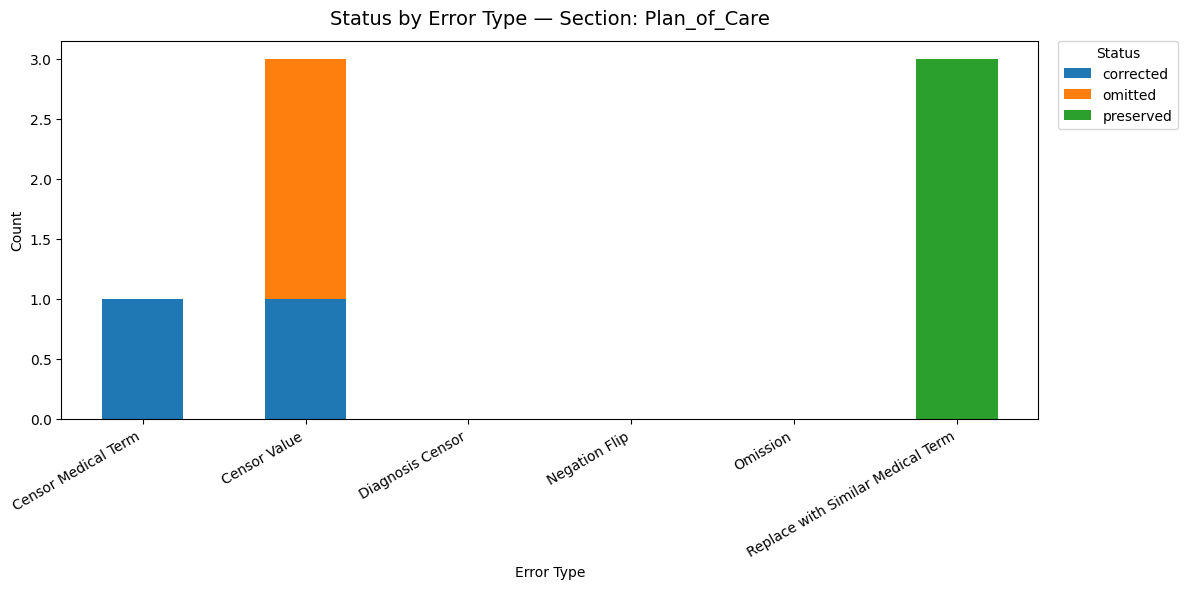

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load and clean data
# -------------------------
df = pd.read_csv("errors_with_status.csv")

# Normalize labels
df["status"] = df["status"].replace(
    "hallucinated and corrected", "corrected"
)

# Ensure categorical columns
cols = ["status", "section", "error_type"]
for c in cols:
    df[c] = df[c].astype("category")

df["status"] = df["status"].cat.as_ordered()

# -------------------------
# Helper plotting function
# -------------------------
def plot_stacked_bar(
    df,
    title,
    xlabel,
    ylabel="Count",
    figsize=(10, 6),
    rotate_xticks=30,
):
    ax = df.plot(
        kind="bar",
        stacked=True,
        figsize=figsize
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=rotate_xticks,
        ha="right"
    )

    ax.legend(
        title="Status",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 1. Overall status distribution
# ============================================================

status_counts = df["status"].value_counts().sort_index()
status_props = status_counts / status_counts.sum()

print("\nOverall status counts")
display(status_counts.to_frame("count"))

print("\nOverall status proportions")
display(status_props.to_frame("proportion").round(3))

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)
plt.title("Distribution of Status", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# ============================================================
# 2. Status by section
# ============================================================

status_by_section = (
    df.groupby(["section", "status"])
      .size()
      .unstack(fill_value=0)
)

status_by_section_props = status_by_section.div(
    status_by_section.sum(axis=1),
    axis=0
)

print("\nStatus by section (counts)")
display(status_by_section)

print("\nStatus by section (proportions)")
display(status_by_section_props.round(3))

plot_stacked_bar(
    status_by_section,
    title="Status Distribution by Section",
    xlabel="Section",
    figsize=(12, 6)
)

# ============================================================
# 3. Status by error type
# ============================================================

status_by_error_type = (
    df.groupby(["error_type", "status"])
      .size()
      .unstack(fill_value=0)
)

status_by_error_type_props = status_by_error_type.div(
    status_by_error_type.sum(axis=1),
    axis=0
)

print("\nStatus by error type (counts)")
display(status_by_error_type)

print("\nStatus by error type (proportions)")
display(status_by_error_type_props.round(3))

plot_stacked_bar(
    status_by_error_type,
    title="Status Distribution by Error Type",
    xlabel="Error Type",
    figsize=(12, 6)
)

# ============================================================
# 4. Error type distribution within each status
# ============================================================

status_error_counts = (
    df.groupby(["status", "error_type"])
      .size()
      .unstack(fill_value=0)
)

status_error_props = status_error_counts.div(
    status_error_counts.sum(axis=1),
    axis=0
)

print("\nError type by status (counts)")
display(status_error_counts)

print("\nError type by status (proportions)")
display(status_error_props.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
status_error_props.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Error Type Distribution by Status (Proportion)",
    fontsize=14,
    pad=12
)
ax.set_xlabel("Status")
ax.set_ylabel("Proportion")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

ax.legend(
    title="Error Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. Status by section AND error type
# ============================================================

status_by_section_error = (
    df.groupby(["section", "error_type", "status"])
      .size()
      .unstack(fill_value=0)
)

for section, subdf in status_by_section_error.groupby(level=0):
    subdf = subdf.droplevel(0)

    print(f"\nSection: {section} — counts")
    display(subdf)

    print(f"Section: {section} — proportions")
    display(
        subdf.div(subdf.sum(axis=1), axis=0).round(3)
    )

    plot_stacked_bar(
        subdf,
        title=f"Status by Error Type — Section: {section}",
        xlabel="Error Type",
        figsize=(12, 6)
    )
